In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CSV_PATH = "/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF/skin_scores_v1.csv"
df = pd.read_csv(CSV_PATH)

print("Rows, Cols:", df.shape)
df.head()

Rows, Cols: (44, 4)


,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count
0,IMG-20260112-WA0000,1.573339,56.522048,200
1,IMG-20260112-WA0001,3.103890,79.265282,211
2,IMG-20260112-WA0002,8.830323,88.438486,224
3,IMG-20260112-WA0003,0.000000,71.581741,321
4,IMG-20260112-WA0004,0.574021,37.625032,203


Parse date from image_id

In [4]:
def parse_date(image_id: str):
    m = re.search(r'(20\d{6})', str(image_id))
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    return pd.NaT

df["date"] = df["image_id"].apply(parse_date)

print("Date parse NA ratio:", df["date"].isna().mean())
print("Date range:", df["date"].min(), "->", df["date"].max())
df.head()

Date parse NA ratio: 0.0
Date range: 2026-01-12 00:00:00 -> 2026-01-16 00:00:00


,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count,date
0,IMG-20260112-WA0000,1.573339,56.522048,200,2026-01-12
1,IMG-20260112-WA0001,3.103890,79.265282,211,2026-01-12
2,IMG-20260112-WA0002,8.830323,88.438486,224,2026-01-12
3,IMG-20260112-WA0003,0.000000,71.581741,321,2026-01-12
4,IMG-20260112-WA0004,0.574021,37.625032,203,2026-01-12


In [5]:
# Keep only rows with valid date
df = df.dropna(subset=["date"]).copy()

# Ensure numeric
for col in ["dark_circle_score", "wrinkle_texture_score", "acne_spot_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("date").reset_index(drop=True)
df.head()

,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count,date
0,IMG-20260112-WA0000,1.573339,56.522048,200,2026-01-12
1,IMG_20260112_205709_227,0.000000,82.719776,1051,2026-01-12
2,IMG_20260112_205702_579,0.000000,85.303805,1209,2026-01-12
3,IMG_20260112_205655_747,0.000000,77.383671,1185,2026-01-12
4,IMG_20260112_205648_543,0.000000,79.112624,1204,2026-01-12


Daily aggregation (multiple photos/day → 1 day)

In [6]:
daily = df.groupby("date").agg(
    photos=("image_id", "count"),
    dark_circle_mean=("dark_circle_score", "mean"),
    dark_circle_median=("dark_circle_score", "median"),
    wrinkle_mean=("wrinkle_texture_score", "mean"),
    wrinkle_median=("wrinkle_texture_score", "median"),
    acne_mean=("acne_spot_count", "mean"),
    acne_median=("acne_spot_count", "median"),
).reset_index()

daily

,date,photos,dark_circle_mean,dark_circle_median,wrinkle_mean,wrinkle_median,acne_mean,acne_median
0,2026-01-12,19,1.825321,0.000000,71.762456,75.472209,662.157895,321.0
1,2026-01-13,9,12.071216,6.302471,71.139524,76.977042,1267.666667,1352.0
2,2026-01-14,10,21.744654,15.050645,55.312821,56.475439,912.700000,794.5
3,2026-01-16,6,0.000000,0.000000,41.826825,41.156869,502.500000,510.5


Acne count কে severity score (0–100) বানানো (Important)

acne_spot_count এখন অনেক বড় (কারণ simple blob detector), তাই UI trend দেখাতে এটা normalize করা ভালো।

👉 আমরা robust scaling করবো: 5th–95th percentile এর মধ্যে map করে 0–100।

In [7]:
def robust_0_100(series):
    s = series.astype(float).copy()
    lo = np.nanpercentile(s, 5)
    hi = np.nanpercentile(s, 95)
    if hi - lo < 1e-9:
        return pd.Series(np.zeros(len(s)), index=s.index)
    x = (s - lo) / (hi - lo)
    x = np.clip(x, 0, 1)
    return x * 100

daily["acne_severity_0_100"] = robust_0_100(daily["acne_mean"])
daily

,date,photos,dark_circle_mean,dark_circle_median,wrinkle_mean,wrinkle_median,acne_mean,acne_median,acne_severity_0_100
0,2026-01-12,19,1.825321,0.000000,71.762456,75.472209,662.157895,321.0,19.725951
1,2026-01-13,9,12.071216,6.302471,71.139524,76.977042,1267.666667,1352.0,100.000000
2,2026-01-14,10,21.744654,15.050645,55.312821,56.475439,912.700000,794.5,56.143384
3,2026-01-16,6,0.000000,0.000000,41.826825,41.156869,502.500000,510.5,0.000000


Rolling trend (7-day rolling mean)

dataset কম দিনের, তবুও structureটা ঠিক রেখে বানাবো।

In [8]:
daily = daily.sort_values("date").set_index("date")

ROLL = 7
daily["dark_circle_roll"] = daily["dark_circle_mean"].rolling(ROLL, min_periods=1).mean()
daily["wrinkle_roll"]     = daily["wrinkle_mean"].rolling(ROLL, min_periods=1).mean()
daily["acne_roll"]        = daily["acne_severity_0_100"].rolling(ROLL, min_periods=1).mean()

daily.reset_index().head()

,date,photos,dark_circle_mean,dark_circle_median,wrinkle_mean,wrinkle_median,acne_mean,acne_median,acne_severity_0_100,dark_circle_roll,wrinkle_roll,acne_roll
0,2026-01-12,19,1.825321,0.000000,71.762456,75.472209,662.157895,321.0,19.725951,1.825321,71.762456,19.725951
1,2026-01-13,9,12.071216,6.302471,71.139524,76.977042,1267.666667,1352.0,100.000000,6.948268,71.450990,59.862975
2,2026-01-14,10,21.744654,15.050645,55.312821,56.475439,912.700000,794.5,56.143384,11.880397,66.071600,58.623112
3,2026-01-16,6,0.000000,0.000000,41.826825,41.156869,502.500000,510.5,0.000000,8.910298,60.010407,43.967334


Plot trends

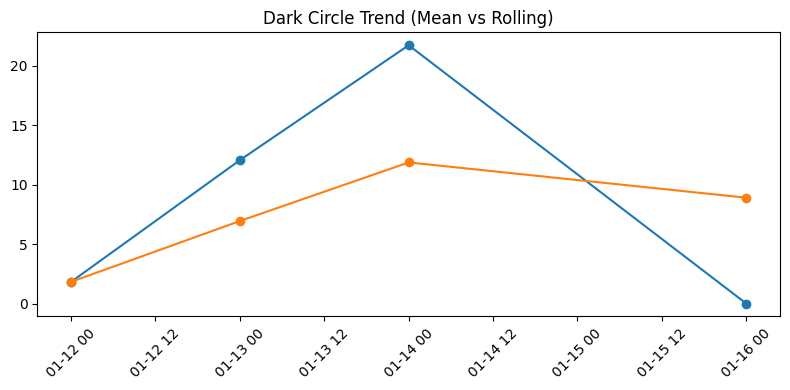

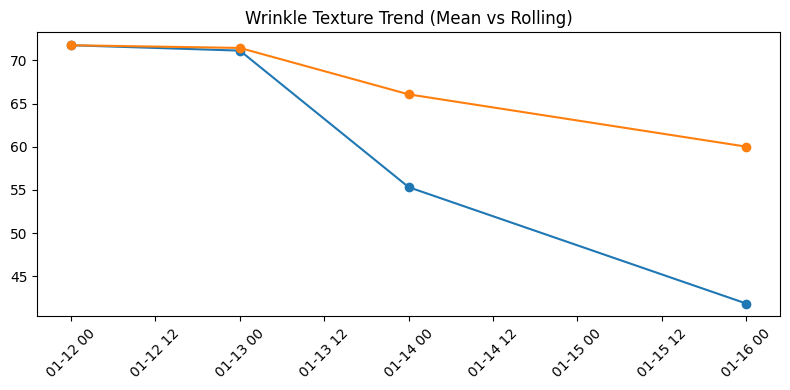

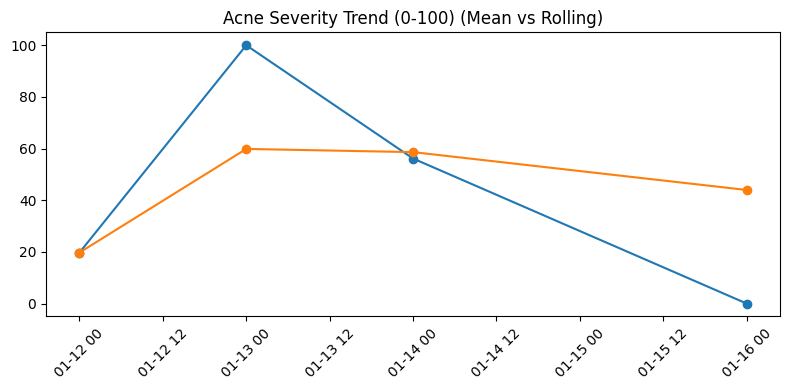

In [9]:
d = daily.reset_index()

# Dark circle
plt.figure(figsize=(8,4))
plt.plot(d["date"], d["dark_circle_mean"], marker="o")
plt.plot(d["date"], d["dark_circle_roll"], marker="o")
plt.title("Dark Circle Trend (Mean vs Rolling)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Wrinkle
plt.figure(figsize=(8,4))
plt.plot(d["date"], d["wrinkle_mean"], marker="o")
plt.plot(d["date"], d["wrinkle_roll"], marker="o")
plt.title("Wrinkle Texture Trend (Mean vs Rolling)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Acne severity
plt.figure(figsize=(8,4))
plt.plot(d["date"], d["acne_severity_0_100"], marker="o")
plt.plot(d["date"], d["acne_roll"], marker="o")
plt.title("Acne Severity Trend (0-100) (Mean vs Rolling)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Simple alert rule (trend spike detection)

MVP rule: আজকের মান যদি গতকালের তুলনায় অনেক বেড়ে যায় → “attention”।

In [10]:
d = daily.reset_index().copy()

def add_spike_alert(col, spike_pct=25):
    # spike_pct = 25 means 25% jump
    prev = d[col].shift(1)
    change = (d[col] - prev) / (prev.replace(0, np.nan))
    d[col + "_spike"] = (change > (spike_pct/100.0)).fillna(False)

add_spike_alert("dark_circle_mean", spike_pct=30)
add_spike_alert("wrinkle_mean", spike_pct=20)
add_spike_alert("acne_severity_0_100", spike_pct=30)

d[["date","photos",
   "dark_circle_mean","dark_circle_mean_spike",
   "wrinkle_mean","wrinkle_mean_spike",
   "acne_severity_0_100","acne_severity_0_100_spike"
  ]]

,date,photos,dark_circle_mean,dark_circle_mean_spike,wrinkle_mean,wrinkle_mean_spike,acne_severity_0_100,acne_severity_0_100_spike
0,2026-01-12,19,1.825321,False,71.762456,False,19.725951,False
1,2026-01-13,9,12.071216,True,71.139524,False,100.000000,True
2,2026-01-14,10,21.744654,True,55.312821,False,56.143384,False
3,2026-01-16,6,0.000000,False,41.826825,False,0.000000,False


Export final daily report CSV

In [14]:
OUT_PATH = "/content/drive/MyDrive/Mirror Vision-KARIGOR/Mirror Vision-KARIGOR_daily_report.csv"
d.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: /content/drive/MyDrive/Mirror Vision-KARIGOR/Mirror Vision-KARIGOR_daily_report.csv
